<a href="https://colab.research.google.com/github/MehemmedTagizade/Thesis_Automated-Investigation-of-Cyber-Attacks-Through-Network-Traffic-Analysis-PCAPs-/blob/TEST-CODES/taks3_improved_Isolation_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the dataset
file_path = '/content/drive/MyDrive/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'


data = pd.read_csv(file_path)


In [ ]:



print(data.columns)  # See the actual column names


Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [ ]:
data.rename(columns=lambda x: x.strip(), inplace=True)


In [ ]:

print(data.columns)


Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [ ]:
import pandas as pd

# Load your dataset (replace 'your_dataset.csv' with the actual filename)


# Check if "Label" column exists
if "Label" in data.columns:
    unique_labels = data["Label"].unique()
    print(f"Unique values in 'Label' column: {unique_labels}")
    print(f"Number of unique values: {len(unique_labels)}")
else:
    print("No 'Label' column found in this dataset.")
# Count occurrences of each label
label_counts = data["Label"].value_counts()

# Convert to percentages
label_percentages = (label_counts / label_counts.sum()) * 100

# Display the results
print(label_percentages)



Unique values in 'Label' column: ['BENIGN' 'DDoS']
Number of unique values: 2
Label
DDoS      56.713105
BENIGN    43.286895
Name: count, dtype: float64


In [ ]:

# Clean column names by removing extra spaces
data.columns = data.columns.str.replace(' ', '')
print(data.columns)

Index(['DestinationPort', 'FlowDuration', 'TotalFwdPackets',
       'TotalBackwardPackets', 'TotalLengthofFwdPackets',
       'TotalLengthofBwdPackets', 'FwdPacketLengthMax', 'FwdPacketLengthMin',
       'FwdPacketLengthMean', 'FwdPacketLengthStd', 'BwdPacketLengthMax',
       'BwdPacketLengthMin', 'BwdPacketLengthMean', 'BwdPacketLengthStd',
       'FlowBytes/s', 'FlowPackets/s', 'FlowIATMean', 'FlowIATStd',
       'FlowIATMax', 'FlowIATMin', 'FwdIATTotal', 'FwdIATMean', 'FwdIATStd',
       'FwdIATMax', 'FwdIATMin', 'BwdIATTotal', 'BwdIATMean', 'BwdIATStd',
       'BwdIATMax', 'BwdIATMin', 'FwdPSHFlags', 'BwdPSHFlags', 'FwdURGFlags',
       'BwdURGFlags', 'FwdHeaderLength', 'BwdHeaderLength', 'FwdPackets/s',
       'BwdPackets/s', 'MinPacketLength', 'MaxPacketLength',
       'PacketLengthMean', 'PacketLengthStd', 'PacketLengthVariance',
       'FINFlagCount', 'SYNFlagCount', 'RSTFlagCount', 'PSHFlagCount',
       'ACKFlagCount', 'URGFlagCount', 'CWEFlagCount', 'ECEFlagCount',
       '

In [ ]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

# Display the first 10 rows of the dataset
print("First 10 rows of the dataset:")
print(data.head(10))



First 10 rows of the dataset:
   DestinationPort  FlowDuration  TotalFwdPackets  TotalBackwardPackets  \
0            54865             3                2                     0   
1            55054           109                1                     1   
2            55055            52                1                     1   
3            46236            34                1                     1   
4            54863             3                2                     0   
5            54871          1022                2                     0   
6            54925             4                2                     0   
7            54925            42                1                     1   
8             9282             4                2                     0   
9            55153             4                2                     0   

   TotalLengthofFwdPackets  TotalLengthofBwdPackets  FwdPacketLengthMax  \
0                       12                        0                  

In [ ]:
print(data.isnull().sum())


DestinationPort            0
FlowDuration               0
TotalFwdPackets            0
TotalBackwardPackets       0
TotalLengthofFwdPackets    0
                          ..
IdleMean                   0
IdleStd                    0
IdleMax                    0
IdleMin                    0
Label                      0
Length: 79, dtype: int64


In [ ]:
print(data['Label'].value_counts())


Label
DDoS      128025
BENIGN     97686
Name: count, dtype: int64


In [ ]:
irrelevant_columns = [
    'FwdPSHFlags', 'BwdPSHFlags', 'FwdURGFlags', 'BwdURGFlags',
    'CWEFlagCount', 'ECEFlagCount', 'FwdHeaderLength.1',
    'FwdAvgBytes/Bulk', 'FwdAvgPackets/Bulk', 'FwdAvgBulkRate',
    'BwdAvgBytes/Bulk', 'BwdAvgPackets/Bulk', 'BwdAvgBulkRate',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward',
    'SubflowFwdPackets', 'SubflowFwdBytes', 'SubflowBwdPackets', 'SubflowBwdBytes',
    'ActiveMean', 'ActiveStd', 'ActiveMax', 'ActiveMin',
    'IdleMean', 'IdleStd', 'IdleMax', 'IdleMin'
]

data = data.drop(columns=irrelevant_columns, errors='ignore')
print(data.columns)
print(len(data.columns))

Index(['DestinationPort', 'FlowDuration', 'TotalFwdPackets',
       'TotalBackwardPackets', 'TotalLengthofFwdPackets',
       'TotalLengthofBwdPackets', 'FwdPacketLengthMax', 'FwdPacketLengthMin',
       'FwdPacketLengthMean', 'FwdPacketLengthStd', 'BwdPacketLengthMax',
       'BwdPacketLengthMin', 'BwdPacketLengthMean', 'BwdPacketLengthStd',
       'FlowBytes/s', 'FlowPackets/s', 'FlowIATMean', 'FlowIATStd',
       'FlowIATMax', 'FlowIATMin', 'FwdIATTotal', 'FwdIATMean', 'FwdIATStd',
       'FwdIATMax', 'FwdIATMin', 'BwdIATTotal', 'BwdIATMean', 'BwdIATStd',
       'BwdIATMax', 'BwdIATMin', 'FwdHeaderLength', 'BwdHeaderLength',
       'FwdPackets/s', 'BwdPackets/s', 'MinPacketLength', 'MaxPacketLength',
       'PacketLengthMean', 'PacketLengthStd', 'PacketLengthVariance',
       'FINFlagCount', 'SYNFlagCount', 'RSTFlagCount', 'PSHFlagCount',
       'ACKFlagCount', 'URGFlagCount', 'Down/UpRatio', 'AveragePacketSize',
       'AvgFwdSegmentSize', 'AvgBwdSegmentSize', 'act_data_pkt_fwd',
 

In [ ]:
begnin_count = data[data['Label'] == 'BENIGN'].shape[0]
print(f"Number of BENIGN samples: {begnin_count}")

ddos_count = data[data['Label'] == 'DDoS'].shape[0]
print(f"Number of DDoS samples: {ddos_count}")

Number of BENIGN samples: 97686
Number of DDoS samples: 128025


In [ ]:
from math import floor
benign_samples = data[data['Label'] == 'BENIGN']
percentage = 0.1
malicious_samples = data[data['Label'] == 'DDoS'].sample(n=floor((begnin_count*percentage)/(1-percentage)), random_state=42)

# Combine the sampled data
data = pd.concat([benign_samples, malicious_samples])

# Shuffle the data
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
print(data['Label'].value_counts())


Label
BENIGN    97686
DDoS      10854
Name: count, dtype: int64


In [ ]:
# Calculate the correlation matrix, ignoring non-numerical columns
correlation_matrix = data.select_dtypes(include=[np.number]).corr()

# Find highly correlated features (e.g., with correlation > 0.9)
high_corr = correlation_matrix[correlation_matrix > 0.9]
print(high_corr)


                         DestinationPort  FlowDuration  TotalFwdPackets  \
DestinationPort                      1.0           NaN              NaN   
FlowDuration                         NaN       1.00000              NaN   
TotalFwdPackets                      NaN           NaN         1.000000   
TotalBackwardPackets                 NaN           NaN         0.964653   
TotalLengthofFwdPackets              NaN           NaN              NaN   
TotalLengthofBwdPackets              NaN           NaN         0.949403   
FwdPacketLengthMax                   NaN           NaN              NaN   
FwdPacketLengthMin                   NaN           NaN              NaN   
FwdPacketLengthMean                  NaN           NaN              NaN   
FwdPacketLengthStd                   NaN           NaN              NaN   
BwdPacketLengthMax                   NaN           NaN              NaN   
BwdPacketLengthMin                   NaN           NaN              NaN   
BwdPacketLengthMean      

DONE++++


Contamination=0.01, n_estimators=100, max_samples=0.5 → F1: 0.8702
Contamination=0.01, n_estimators=100, max_samples=1.0 → F1: 0.8695
Contamination=0.01, n_estimators=200, max_samples=0.5 → F1: 0.8601
Contamination=0.01, n_estimators=200, max_samples=1.0 → F1: 0.8678
Contamination=0.03, n_estimators=100, max_samples=0.5 → F1: 0.8691
Contamination=0.03, n_estimators=100, max_samples=1.0 → F1: 0.8676
Contamination=0.03, n_estimators=200, max_samples=0.5 → F1: 0.8678
Contamination=0.03, n_estimators=200, max_samples=1.0 → F1: 0.8681
Contamination=0.05, n_estimators=100, max_samples=0.5 → F1: 0.8567
Contamination=0.05, n_estimators=100, max_samples=1.0 → F1: 0.8567
Contamination=0.05, n_estimators=200, max_samples=0.5 → F1: 0.8566
Contamination=0.05, n_estimators=200, max_samples=1.0 → F1: 0.8564

✅ Best Params → Contamination=0.01, n_estimators=100, max_samples=0.5 with F1=0.8702

✅ Test Accuracy: 0.8810

=== Final Test Set Results ===
              precision    recall  f1-score   support

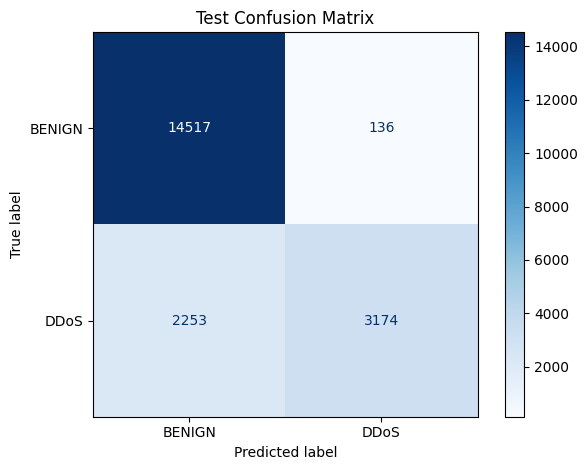

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from itertools import product

# === Step 1: Prepare features and labels ===
labels = data['Label'].values
features = data.drop(columns=['Label'])

# Encode labels (BENIGN = 0, DDoS = 1)
y_encoded = np.where(labels == 'BENIGN', 0, 1)

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# === Step 2: Separate BENIGN and DDoS samples ===
X_benign = features_scaled[y_encoded == 0]
X_ddos = features_scaled[y_encoded == 1]

# === Step 3: Split BENIGN into train/cv/test ===
n_benign = len(X_benign)
np.random.seed(42)
idx = np.random.permutation(n_benign)

train_end = int(0.7 * n_benign)
cv_end = int(0.85 * n_benign)

X_train = X_benign[idx[:train_end]]
X_cv_benign = X_benign[idx[train_end:cv_end]]
X_test_benign = X_benign[idx[cv_end:]]

# === Step 4: Split DDoS into cv/test ===
n_ddos = len(X_ddos)
np.random.seed(42)
idx_ddos = np.random.permutation(n_ddos)
half = n_ddos // 2

X_cv_ddos = X_ddos[idx_ddos[:half]]
X_test_ddos = X_ddos[idx_ddos[half:]]

# === Step 5: Create CV and Test Sets ===
X_cv = np.vstack((X_cv_benign, X_cv_ddos))
y_cv = np.concatenate((np.zeros(len(X_cv_benign)), np.ones(len(X_cv_ddos))))

X_test = np.vstack((X_test_benign, X_test_ddos))
y_test = np.concatenate((np.zeros(len(X_test_benign)), np.ones(len(X_test_ddos))))

# === Step 6: Define hyperparameter grid ===
contamination_list = [0.01, 0.03, 0.05]
n_estimators_list = [100, 200]
max_samples_list = [0.5, 1.0]

param_grid = list(product(contamination_list, n_estimators_list, max_samples_list))
results = []

# === Step 7: Grid Search on CV Set ===
for contamination, n_estimators, max_samples in param_grid:
    model = IsolationForest(
        contamination=contamination,
        n_estimators=n_estimators,
        max_samples=max_samples,
        random_state=42
    )
    model.fit(X_train)
    preds = model.predict(X_cv)
    preds = np.where(preds == -1, 1, 0)

    report = classification_report(y_cv, preds, output_dict=True)
    f1 = report['weighted avg']['f1-score']
    results.append(((contamination, n_estimators, max_samples), f1))

    print(f"Contamination={contamination}, n_estimators={n_estimators}, max_samples={max_samples} → F1: {f1:.4f}")

# === Step 8: Report best config ===
best = max(results, key=lambda x: x[1])
best_params = best[0]
print(f"\n✅ Best Params → Contamination={best_params[0]}, n_estimators={best_params[1]}, max_samples={best_params[2]} with F1={best[1]:.4f}")

# === Step 9: Retrain with best config and evaluate on TEST set ===
model = IsolationForest(
    contamination=best_params[0],
    n_estimators=best_params[1],
    max_samples=best_params[2],
    random_state=42
)
model.fit(X_train)
test_preds = model.predict(X_test)
test_preds = np.where(test_preds == -1, 1, 0)

# === Accuracy Calculation ===
accuracy = accuracy_score(y_test, test_preds)
print(f"\n✅ Test Accuracy: {accuracy:.4f}")

# === Final Evaluation ===
print("\n=== Final Test Set Results ===")
print(classification_report(y_test, test_preds))
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=['BENIGN', 'DDoS'], cmap='Blues')
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.show()

Contamination=0.01, n_estimators=100, max_samples=0.5 → F1: 0.9002
Contamination=0.01, n_estimators=100, max_samples=1.0 → F1: 0.9153
Contamination=0.01, n_estimators=200, max_samples=0.5 → F1: 0.8989
Contamination=0.01, n_estimators=200, max_samples=1.0 → F1: 0.9095
Contamination=0.03, n_estimators=100, max_samples=0.5 → F1: 0.9031
Contamination=0.03, n_estimators=100, max_samples=1.0 → F1: 0.9033
Contamination=0.03, n_estimators=200, max_samples=0.5 → F1: 0.9026
Contamination=0.03, n_estimators=200, max_samples=1.0 → F1: 0.9030
Contamination=0.05, n_estimators=100, max_samples=0.5 → F1: 0.8892
Contamination=0.05, n_estimators=100, max_samples=1.0 → F1: 0.8893
Contamination=0.05, n_estimators=200, max_samples=0.5 → F1: 0.8889
Contamination=0.05, n_estimators=200, max_samples=1.0 → F1: 0.8890

✅ Best Params → Contamination=0.01, n_estimators=100, max_samples=1.0 with F1=0.9153

✅ Test Accuracy: 0.9222

=== Final Test Set Results ===
              precision    recall  f1-score   support

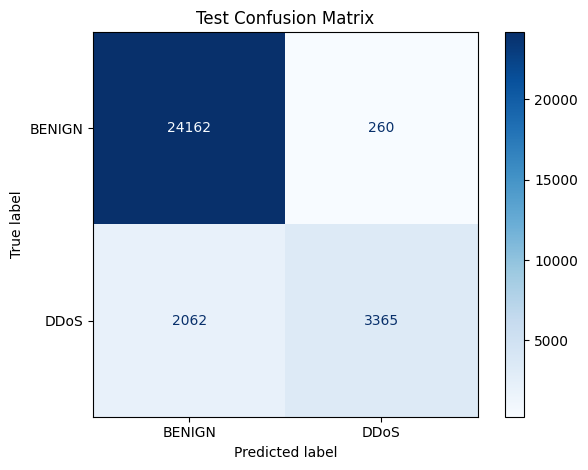

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from itertools import product

# === Step 1: Prepare features and labels ===
labels = data['Label'].values
features = data.drop(columns=['Label'])

# Encode labels (BENIGN = 0, DDoS = 1)
y_encoded = np.where(labels == 'BENIGN', 0, 1)

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# === Step 2: Separate BENIGN and DDoS samples ===
X_benign = features_scaled[y_encoded == 0]
X_ddos = features_scaled[y_encoded == 1]

# === Step 3: Split BENIGN into train/cv/test ===
n_benign = len(X_benign)
np.random.seed(42)
idx = np.random.permutation(n_benign)

train_end = int(0.5 * n_benign)
cv_end = int(0.75 * n_benign)

X_train = X_benign[idx[:train_end]]
X_cv_benign = X_benign[idx[train_end:cv_end]]
X_test_benign = X_benign[idx[cv_end:]]

# === Step 4: Split DDoS into cv/test ===
n_ddos = len(X_ddos)
np.random.seed(42)
idx_ddos = np.random.permutation(n_ddos)
half = n_ddos // 2

X_cv_ddos = X_ddos[idx_ddos[:half]]
X_test_ddos = X_ddos[idx_ddos[half:]]

# === Step 5: Create CV and Test Sets ===
X_cv = np.vstack((X_cv_benign, X_cv_ddos))
y_cv = np.concatenate((np.zeros(len(X_cv_benign)), np.ones(len(X_cv_ddos))))

X_test = np.vstack((X_test_benign, X_test_ddos))
y_test = np.concatenate((np.zeros(len(X_test_benign)), np.ones(len(X_test_ddos))))

# === Step 6: Define hyperparameter grid ===
contamination_list = [0.01, 0.03, 0.05]
n_estimators_list = [100, 200]
max_samples_list = [0.5, 1.0]

param_grid = list(product(contamination_list, n_estimators_list, max_samples_list))
results = []

# === Step 7: Grid Search on CV Set ===
for contamination, n_estimators, max_samples in param_grid:
    model = IsolationForest(
        contamination=contamination,
        n_estimators=n_estimators,
        max_samples=max_samples,
        random_state=42
    )
    model.fit(X_train)
    preds = model.predict(X_cv)
    preds = np.where(preds == -1, 1, 0)

    report = classification_report(y_cv, preds, output_dict=True)
    f1 = report['weighted avg']['f1-score']
    results.append(((contamination, n_estimators, max_samples), f1))

    print(f"Contamination={contamination}, n_estimators={n_estimators}, max_samples={max_samples} → F1: {f1:.4f}")

# === Step 8: Report best config ===
best = max(results, key=lambda x: x[1])
best_params = best[0]
print(f"\n✅ Best Params → Contamination={best_params[0]}, n_estimators={best_params[1]}, max_samples={best_params[2]} with F1={best[1]:.4f}")

# === Step 9: Retrain with best config and evaluate on TEST set ===
model = IsolationForest(
    contamination=best_params[0],
    n_estimators=best_params[1],
    max_samples=best_params[2],
    random_state=42
)
model.fit(X_train)
test_preds = model.predict(X_test)
test_preds = np.where(test_preds == -1, 1, 0)

# === Accuracy Calculation ===
accuracy = accuracy_score(y_test, test_preds)
print(f"\n✅ Test Accuracy: {accuracy:.4f}")

# === Final Evaluation ===
print("\n=== Final Test Set Results ===")
print(classification_report(y_test, test_preds))
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=['BENIGN', 'DDoS'], cmap='Blues')
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.show()


✅ Test Accuracy: 0.8019

=== Final Test Set Results ===
              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89     19538
         1.0       0.98      0.09      0.17      5427

    accuracy                           0.80     24965
   macro avg       0.89      0.55      0.53     24965
weighted avg       0.84      0.80      0.73     24965



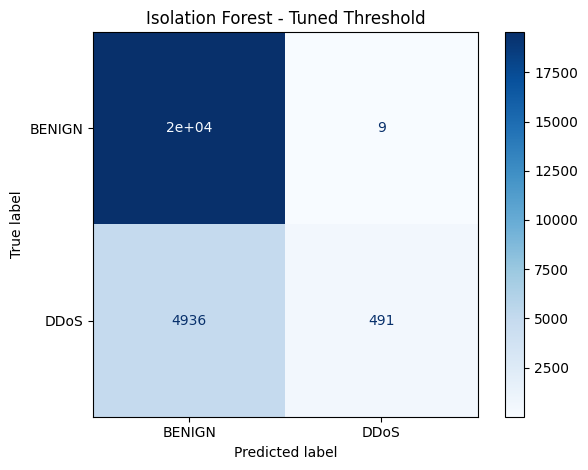

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# === Step 1: Prepare features and labels ===
labels = data['Label'].values
features = data.drop(columns=['Label'])

# Encode labels (BENIGN = 0, DDoS = 1)
y_encoded = np.where(labels == 'BENIGN', 0, 1)

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# === Step 2: Separate BENIGN and DDoS samples ===
X_benign = features_scaled[y_encoded == 0]
X_ddos = features_scaled[y_encoded == 1]

# === Step 3: Split BENIGN into train/cv/test ===
n_benign = len(X_benign)
np.random.seed(42)
idx = np.random.permutation(n_benign)

train_end = int(0.6 * n_benign)
cv_end = int(0.8 * n_benign)

X_train = X_benign[idx[:train_end]]
X_cv_benign = X_benign[idx[train_end:cv_end]]
X_test_benign = X_benign[idx[cv_end:]]

# === Step 4: Split DDoS into cv/test ===
n_ddos = len(X_ddos)
idx_ddos = np.random.permutation(n_ddos)
half = n_ddos // 2

X_cv_ddos = X_ddos[idx_ddos[:half]]
X_test_ddos = X_ddos[idx_ddos[half:]]

# === Step 5: Create CV and Test Sets ===
X_cv = np.vstack((X_cv_benign, X_cv_ddos))
y_cv = np.concatenate((np.zeros(len(X_cv_benign)), np.ones(len(X_cv_ddos))))

X_test = np.vstack((X_test_benign, X_test_ddos))
y_test = np.concatenate((np.zeros(len(X_test_benign)), np.ones(len(X_test_ddos))))

# === Step 6: Train Isolation Forest ===
model = IsolationForest(
    contamination=0.01,  # You can try 0.015 or 0.02 for better recall
    n_estimators=100,
    max_samples=1.0,
    random_state=42
)
model.fit(X_train)

# === Step 7: Use decision_function and custom threshold ===
scores_test = model.decision_function(X_test)

# 🔧 TUNABLE THRESHOLD — increase this percentile to reduce FN
threshold = np.percentile(scores_test, 2.0)  # Try 4.0 or 5.0 for better recall
test_preds = (scores_test < threshold).astype(int)

# === Step 8: Evaluate Performance ===
accuracy = accuracy_score(y_test, test_preds)
print(f"\n✅ Test Accuracy: {accuracy:.4f}")
print("\n=== Final Test Set Results ===")
print(classification_report(y_test, test_preds))

# === Step 9: Show Confusion Matrix ===
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=['BENIGN', 'DDoS'], cmap='Blues')
plt.title("Isolation Forest - Tuned Threshold")
plt.tight_layout()
plt.show()


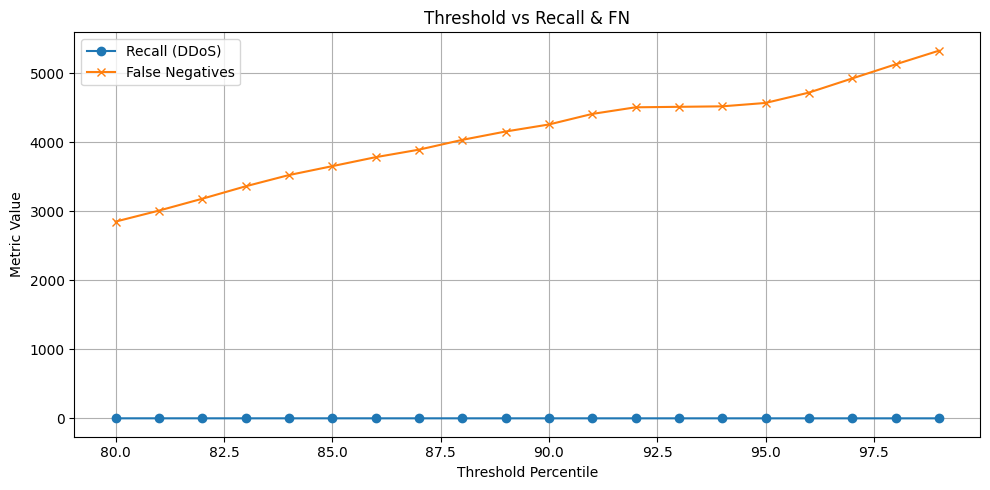

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, recall_score
import matplotlib.pyplot as plt

# === Step 1: Prepare features and labels ===
labels = data['Label'].values
features = data.drop(columns=['Label'])

# Encode labels (BENIGN = 0, DDoS = 1)
y_encoded = np.where(labels == 'BENIGN', 0, 1)

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# === Step 2: Separate BENIGN and DDoS samples ===
X_benign = features_scaled[y_encoded == 0]
X_ddos = features_scaled[y_encoded == 1]

# === Step 3: Split BENIGN into train/cv/test ===
n_benign = len(X_benign)
np.random.seed(42)
idx = np.random.permutation(n_benign)

train_end = int(0.6 * n_benign)
cv_end = int(0.8 * n_benign)

X_train = X_benign[idx[:train_end]]
X_cv_benign = X_benign[idx[train_end:cv_end]]
X_test_benign = X_benign[idx[cv_end:]]

# === Step 4: Split DDoS into cv/test ===
n_ddos = len(X_ddos)
np.random.seed(42)
idx_ddos = np.random.permutation(n_ddos)
half = n_ddos // 2

X_cv_ddos = X_ddos[idx_ddos[:half]]
X_test_ddos = X_ddos[idx_ddos[half:]]

# === Step 5: Create CV and Test Sets ===
X_cv = np.vstack((X_cv_benign, X_cv_ddos))
y_cv = np.concatenate((np.zeros(len(X_cv_benign)), np.ones(len(X_cv_ddos))))

X_test = np.vstack((X_test_benign, X_test_ddos))
y_test = np.concatenate((np.zeros(len(X_test_benign)), np.ones(len(X_test_ddos))))

# === Step 6: Train Isolation Forest ===
model = IsolationForest(contamination=0.1, random_state=42)
model.fit(X_train)

# === Step 7: Use decision_function and loop through thresholds ===
scores_test = -model.decision_function(X_test)  # Flip sign: higher = more anomalous
thresholds = np.percentile(scores_test, np.arange(80, 100, 1))
recalls = []
false_negatives = []

for t in thresholds:
    preds = (scores_test > t).astype(int)
    recall = recall_score(y_test, preds)

    cm = confusion_matrix(y_test, preds)
    fn = cm[1][0]  # False Negatives: actual 1 predicted 0

    recalls.append(recall)
    false_negatives.append(fn)

# === Step 8: Plot recall and FN vs threshold ===
plt.figure(figsize=(10,5))
plt.plot(np.arange(80, 100, 1), recalls, label='Recall (DDoS)', marker='o')
plt.plot(np.arange(80, 100, 1), false_negatives, label='False Negatives', marker='x')
plt.title("Threshold vs Recall & FN")
plt.xlabel("Threshold Percentile")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



✅ Accuracy: 0.8188

=== Classification Report ===
              precision    recall  f1-score   support

         0.0       0.97      0.83      0.90     73265
         1.0       0.22      0.64      0.33      5427

    accuracy                           0.82     78692
   macro avg       0.59      0.73      0.61     78692
weighted avg       0.92      0.82      0.86     78692



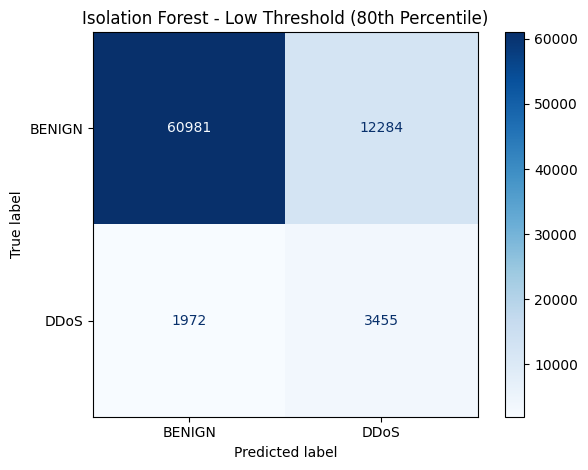

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# === Step 1: Prepare features and labels ===
labels = data['Label'].values
features = data.drop(columns=['Label'])

# Encode labels (BENIGN = 0, DDoS = 1)
y_encoded = np.where(labels == 'BENIGN', 0, 1)

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# === Step 2: Separate BENIGN and DDoS samples ===
X_benign = features_scaled[y_encoded == 0]
X_ddos = features_scaled[y_encoded == 1]

# === Step 3: Split BENIGN into train/cv/test ===
n_benign = len(X_benign)
np.random.seed(42)
idx = np.random.permutation(n_benign)

train_end = int(0.5 * n_benign)
cv_end = int(0.25 * n_benign)

X_train = X_benign[idx[:train_end]]
X_cv_benign = X_benign[idx[train_end:cv_end]]
X_test_benign = X_benign[idx[cv_end:]]

# === Step 4: Split DDoS into cv/test ===
n_ddos = len(X_ddos)
np.random.seed(42)
idx_ddos = np.random.permutation(n_ddos)
half = n_ddos // 2

X_cv_ddos = X_ddos[idx_ddos[:half]]
X_test_ddos = X_ddos[idx_ddos[half:]]

# === Step 5: Create CV and Test Sets ===
X_cv = np.vstack((X_cv_benign, X_cv_ddos))
y_cv = np.concatenate((np.zeros(len(X_cv_benign)), np.ones(len(X_cv_ddos))))

X_test = np.vstack((X_test_benign, X_test_ddos))
y_test = np.concatenate((np.zeros(len(X_test_benign)), np.ones(len(X_test_ddos))))

# === Step 6: Train Isolation Forest ===
model = IsolationForest(
    contamination=0.1,  # Can try 0.15 to widen anomaly detection
    n_estimators=100,
    max_samples=1.0,
    random_state=42
)
model.fit(X_train)

# === Step 7: Predict with custom threshold to reduce FN ===
scores_test = -model.decision_function(X_test)  # Higher = more anomalous
threshold = np.percentile(scores_test, 80)  # Lower threshold = more alerts → lower FN
test_preds = (scores_test > threshold).astype(int)

# === Step 8: Evaluation ===
accuracy = accuracy_score(y_test, test_preds)
print(f"\n✅ Accuracy: {accuracy:.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, test_preds))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=['BENIGN', 'DDoS'], cmap='Blues')
plt.title("Isolation Forest - Low Threshold (80th Percentile)")
plt.tight_layout()
plt.show()
